In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [10]:
df=pd.read_csv('iris.csv')
df.columns = [c.strip().lower() for c in df.columns]

In [18]:
label_col = "species" if "species" in df.columns else "class"

Label column: species


In [14]:
exclude_names = {"id", "index", "unnamed: 0"}
feature_cols = [c for c in df.columns if c != label_col and c not in exclude_names]
feature_names = feature_cols

In [15]:
print(feature_names)

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [21]:
X = df[feature_cols].to_numpy(dtype=float)
labels_raw = df[label_col].to_numpy()
class_names = sorted(set(labels_raw))

In [23]:
sample_indices = [int(np.where(labels_raw == cls)[0][0]) for cls in class_names]
samples_raw = X[sample_indices]
sample_labels = [labels_raw[i] for i in sample_indices]

In [24]:
print("Selected Iris samples (one per class):")
for idx, label, row in zip(sample_indices, sample_labels, samples_raw):
    print(f"  [{str(label):20s}] {feature_names} = {row}")

Selected Iris samples (one per class):
  [setosa              ] ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'] = [5.1 3.5 1.4 0.2]
  [versicolor          ] ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'] = [7.  3.2 4.7 1.4]
  [virginica           ] ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'] = [6.3 3.3 6.  2.5]


In [25]:
def min_max_scale(data, feature_range=(0, 1)):
    
    lo, hi = feature_range
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    scale = (data - data_min) / (data_max - data_min)
    return scale * (hi - lo) + lo
 
 
# Scale to [0, 2*pi] for angle/phase-based encodings
samples_angle_scaled = min_max_scale(X, feature_range=(0, 2 * np.pi))[sample_indices]
 
# Scale to [0, 1] for amplitude encoding
samples_amp_scaled = min_max_scale(X, feature_range=(0, 1))[sample_indices]
 
 
def normalize_for_amplitude(vec):
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

In [29]:

def basis_encoding(sample_scaled_01, n_bits_per_feature=2):
    """
    Discretize each of the 4 features into n_bits_per_feature bits,
    then flip qubits to represent that bitstring (X gates on 1-bits).
    Lossy: continuous Iris values are binned into discrete levels.
    """
    n_qubits = 4 * n_bits_per_feature
    qc = QuantumCircuit(n_qubits, name="BasisEncoding")
 
    bitstring = ""
    for feature_val in sample_scaled_01:
        level = int(round(feature_val * (2 ** n_bits_per_feature - 1)))
        bits = format(level, f"0{n_bits_per_feature}b")
        bitstring += bits
 
    for i, bit in enumerate(bitstring):
        if bit == "1":
            qc.x(i)
 
    return qc, bitstring
 
 
def angle_encoding(sample_scaled_2pi):
    """
    Each of the 4 features becomes a rotation angle on its own qubit: x_i -> RY(x_i)
    """
    n_qubits = len(sample_scaled_2pi)
    qc = QuantumCircuit(n_qubits, name="AngleEncoding")
    for i, angle in enumerate(sample_scaled_2pi):
        qc.ry(angle, i)
    return qc
 
 
def amplitude_encoding(sample_scaled_01):
    """
    The 4 classical feature values become amplitudes of a 2-qubit statevector
    (4 amplitudes = 2^2 states), after normalization.
    """
    normalized = normalize_for_amplitude(sample_scaled_01)
    n_qubits = int(np.ceil(np.log2(len(normalized))))
    qc = QuantumCircuit(n_qubits, name="AmplitudeEncoding")
    qc.prepare_state(Statevector(normalized).data, range(n_qubits))
    return qc, normalized
 
 
def phase_encoding(sample_scaled_2pi):
    """
    Each feature becomes a relative phase applied via a phase gate,
    after putting each qubit into superposition with H first.
    """
    n_qubits = len(sample_scaled_2pi)
    qc = QuantumCircuit(n_qubits, name="PhaseEncoding")
    for i, angle in enumerate(sample_scaled_2pi):
        qc.h(i)
        qc.p(angle, i)
    return qc
 
 
def dense_encoding(sample_scaled_2pi):
    """
    Packs more information per qubit by combining rotation angle AND phase
    on the same qubit (2 classical values per qubit instead of 1),
    using pairs of features -> 2 qubits for 4 features.
    """
    n_features = len(sample_scaled_2pi)
    n_qubits = n_features // 2
    qc = QuantumCircuit(n_qubits, name="DenseEncoding")
    for i in range(n_qubits):
        rot_val = sample_scaled_2pi[2 * i]
        phase_val = sample_scaled_2pi[2 * i + 1]
        qc.ry(rot_val, i)
        qc.p(phase_val, i)
    return qc
 
 
# -------------------------------------------------------------------
# 3. Run all 5 encodings on each sample and inspect resulting states
# -------------------------------------------------------------------
if __name__ == "__main__":
    for idx in range(len(sample_indices)):
        label = sample_labels[idx]
        raw = samples_raw[idx]
        angle_scaled = samples_angle_scaled[idx]
        amp_scaled = samples_amp_scaled[idx]
 
        print("\n" + "=" * 70)
        print(f"Sample: {label}  |  raw features = {raw}")
        print("=" * 70)
 
        # Basis encoding
        qc_basis, bitstring = basis_encoding(amp_scaled)
        print(f"\n[Basis Encoding]  n_qubits={qc_basis.num_qubits}  bitstring={bitstring}")
        print(qc_basis.draw(output="text"))
 
        # Angle encoding
        qc_angle = angle_encoding(angle_scaled)
        sv_angle = Statevector.from_instruction(qc_angle)
        print(f"\n[Angle Encoding]  n_qubits={qc_angle.num_qubits}")
        print(qc_angle.draw(output="text"))
        print(f"Statevector (first 4 amplitudes): {sv_angle.data[:4]}")
 
        # Amplitude encoding
        qc_amp, normalized_vec = amplitude_encoding(amp_scaled)
        sv_amp = Statevector.from_instruction(qc_amp)
        print(f"\n[Amplitude Encoding]  n_qubits={qc_amp.num_qubits}")
        print(f"Normalized amplitude vector: {normalized_vec}")
        print(f"Resulting statevector: {sv_amp.data}")
 
        # Phase encoding
        qc_phase = phase_encoding(angle_scaled)
        sv_phase = Statevector.from_instruction(qc_phase)
        print(f"\n[Phase Encoding]  n_qubits={qc_phase.num_qubits}")
        print(qc_phase.draw(output="text"))
        print(f"Statevector (first 4 amplitudes): {sv_phase.data[:4]}")
 
        # Dense encoding
        qc_dense = dense_encoding(angle_scaled)
        sv_dense = Statevector.from_instruction(qc_dense)
        print(f"\n[Dense Encoding]  n_qubits={qc_dense.num_qubits}")
        print(qc_dense.draw(output="text"))
        print(f"Statevector: {sv_dense.data}")


Sample: setosa  |  raw features = [5.1 3.5 1.4 0.2]

[Basis Encoding]  n_qubits=8  bitstring=01100000
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     ├───┤
q_2: ┤ X ├
     └───┘
q_3: ─────
          
q_4: ─────
          
q_5: ─────
          
q_6: ─────
          
q_7: ─────
          

[Angle Encoding]  n_qubits=4
       ┌──────────┐ 
q_0: ──┤ Ry(4π/9) ├─
       ├──────────┤ 
q_1: ──┤ Ry(5π/4) ├─
     ┌─┴──────────┴┐
q_2: ┤ Ry(0.42598) ├
     └─┬──────────┬┘
q_3: ──┤ Ry(π/12) ├─
       └──────────┘ 
Statevector (first 4 amplitudes): [-0.28407697+0.j -0.23836888+0.j  0.68582249+0.j  0.57547339+0.j]

[Amplitude Encoding]  n_qubits=2
Normalized amplitude vector: [0.33262469 0.93550694 0.10147872 0.06236713]
Resulting statevector: [0.33262469+1.10110771e-16j 0.93550694-1.51467321e-16j
 0.10147872-1.12385038e-17j 0.06236713+5.34699649e-18j]

[Phase Encoding]  n_qubits=4
     ┌───┐ ┌─────────┐  
q_0: ┤ H ├─┤ P(4π/9) ├──
     ├───┤ ├─────────┤  
q_1: ┤ H ├─┤ P(5π/4) ├──
     ├───┤┌┴──────

In [31]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import z_feature_map, zz_feature_map, pauli_feature_map
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit_aer import AerSimulator

In [34]:
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import z_feature_map, zz_feature_map, pauli_feature_map
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit_aer import AerSimulator
 
# -------------------------------------------------------------------
# 1. Load the same Iris samples used in Layer 1
# -------------------------------------------------------------------
df = pd.read_csv("iris.csv")
df.columns = [c.strip().lower() for c in df.columns]
label_col = "species" if "species" in df.columns else "class"
exclude_names = {"id", "index", "unnamed: 0"}
feature_cols = [c for c in df.columns if c != label_col and c not in exclude_names]
 
X = df[feature_cols].to_numpy(dtype=float)
labels_raw = df[label_col].to_numpy()
class_names = sorted(set(labels_raw))
 
sample_indices = [int(np.where(labels_raw == cls)[0][0]) for cls in class_names]
samples_raw = X[sample_indices]
sample_labels = [labels_raw[i] for i in sample_indices]
 
 
def min_max_scale(data, feature_range=(0, 1)):
    lo, hi = feature_range
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    scale = (data - data_min) / (data_max - data_min)
    return scale * (hi - lo) + lo
 
 
# Feature maps expect bounded, consistently scaled input — reuse angle-style scaling
samples_scaled = min_max_scale(X, feature_range=(0, 2 * np.pi))[sample_indices]
 
FEATURE_DIM = X.shape[1]  # 4
REPS = 2  # consistent across all three feature maps
 

In [35]:
feature_maps = {
    "ZFeatureMap": z_feature_map(feature_dimension=FEATURE_DIM, reps=REPS),
    "ZZFeatureMap": zz_feature_map(feature_dimension=FEATURE_DIM, reps=REPS),
    "PauliFeatureMap": pauli_feature_map(
        feature_dimension=FEATURE_DIM, reps=REPS, paulis=["Z", "Y", "ZZ"]
    ),
}
 
 
def bind_params(fmap: QuantumCircuit, values: np.ndarray) -> QuantumCircuit:
    """Bind a sample's feature values to a feature map's free parameters."""
    param_dict = dict(zip(fmap.parameters, values))
    return fmap.assign_parameters(param_dict)
 
 
# -------------------------------------------------------------------
# 3. Circuit depth and gate count comparison
# -------------------------------------------------------------------
def gate_count_breakdown(qc: QuantumCircuit):
    decomposed = qc.decompose()
    ops = decomposed.count_ops()
    two_qubit_gate_names = {"cx", "cz", "rzz", "rxx", "ryy", "ecr", "swap"}
    two_qubit = sum(c for g, c in ops.items() if g in two_qubit_gate_names)
    total = sum(ops.values())
    single_qubit = total - two_qubit
    return {
        "depth": decomposed.depth(),
        "total_gates": total,
        "single_qubit_gates": single_qubit,
        "two_qubit_gates": two_qubit,
        "ops": dict(ops),
    }
 
 

In [36]:
# 3. Circuit depth and gate count comparison
# -------------------------------------------------------------------
def gate_count_breakdown(qc: QuantumCircuit):
    decomposed = qc.decompose()
    ops = decomposed.count_ops()
    two_qubit_gate_names = {"cx", "cz", "rzz", "rxx", "ryy", "ecr", "swap"}
    two_qubit = sum(c for g, c in ops.items() if g in two_qubit_gate_names)
    total = sum(ops.values())
    single_qubit = total - two_qubit
    return {
        "depth": decomposed.depth(),
        "total_gates": total,
        "single_qubit_gates": single_qubit,
        "two_qubit_gates": two_qubit,
        "ops": dict(ops),
    }
 
 

In [37]:
def meyer_wallach_measure(statevector: Statevector, n_qubits: int) -> float:
    """
    Q = (2/n) * sum_k [1 - Tr(rho_k^2)]
    where rho_k is the reduced density matrix of qubit k.
    Q ranges 0 (no entanglement) to 1 (maximal multipartite entanglement).
    """
    total = 0.0
    for k in range(n_qubits):
        trace_out = [q for q in range(n_qubits) if q != k]
        rho_k = partial_trace(statevector, trace_out)
        purity = np.real(np.trace(rho_k.data @ rho_k.data))
        total += 1 - purity
    return (2 / n_qubits) * total
 
 

In [38]:
BASIS_GATES = ["cx", "rz", "sx", "x"]
 
 
def transpile_comparison(qc: QuantumCircuit):
    original = gate_count_breakdown(qc)
    transpiled_qc = transpile(qc, basis_gates=BASIS_GATES, optimization_level=1)
    transpiled = {
        "depth": transpiled_qc.depth(),
        "total_gates": sum(transpiled_qc.count_ops().values()),
        "two_qubit_gates": transpiled_qc.count_ops().get("cx", 0),
    }
    return original, transpiled
 
 

In [39]:
def measurement_distribution(qc: QuantumCircuit, shots=4000):
    meas_qc = qc.copy()
    meas_qc.measure_all()
    simulator = AerSimulator()
    transpiled = transpile(meas_qc, simulator)
    result = simulator.run(transpiled, shots=shots).result()
    counts = result.get_counts()
    return counts
 

In [40]:
#-------------------------------------------------------------------
if __name__ == "__main__":
    all_results = []
 
    for idx in range(len(sample_indices)):
        label = sample_labels[idx]
        values = samples_scaled[idx]
 
        print("\n" + "=" * 70)
        print(f"Sample: {label}  |  scaled features = {np.round(values, 3)}")
        print("=" * 70)
 
        for name, fmap in feature_maps.items():
            bound = bind_params(fmap, values)
            metrics = gate_count_breakdown(bound)
            sv = Statevector.from_instruction(bound)
            entanglement = meyer_wallach_measure(sv, bound.num_qubits)
            orig, transpiled = transpile_comparison(bound)
            counts = measurement_distribution(bound)
 
            print(f"\n[{name}]")
            print(f"  n_qubits          : {bound.num_qubits}")
            print(f"  depth             : {metrics['depth']}")
            print(f"  total_gates       : {metrics['total_gates']}")
            print(f"  single_qubit_gates: {metrics['single_qubit_gates']}")
            print(f"  two_qubit_gates   : {metrics['two_qubit_gates']}")
            print(f"  Meyer-Wallach Q   : {entanglement:.4f}")
            print(f"  transpiled_depth  : {transpiled['depth']}  (was {orig['depth']})")
            print(f"  transpiled_2q_gates: {transpiled['two_qubit_gates']}  (was {orig['two_qubit_gates']})")
            print(f"  top measurement outcomes: {sorted(counts.items(), key=lambda x: -x[1])[:4]}")
 
            all_results.append({
                "sample": label,
                "feature_map": name,
                "n_qubits": bound.num_qubits,
                "depth": metrics["depth"],
                "total_gates": metrics["total_gates"],
                "single_qubit_gates": metrics["single_qubit_gates"],
                "two_qubit_gates": metrics["two_qubit_gates"],
                "meyer_wallach_Q": entanglement,
                "transpiled_depth": transpiled["depth"],
                "transpiled_two_qubit_gates": transpiled["two_qubit_gates"],
            })
 
    # Summary table
    results_df = pd.DataFrame(all_results)
    print("\n\n" + "=" * 70)
    print("SUMMARY TABLE")
    print("=" * 70)
    print(results_df.to_string(index=False))
 
    results_df.to_csv("layer2_feature_map_comparison.csv", index=False)
    print("\nSaved summary to layer2_feature_map_comparison.csv")
 


Sample: setosa  |  scaled features = [1.396 3.927 0.426 0.262]

[ZFeatureMap]
  n_qubits          : 4
  depth             : 4
  total_gates       : 16
  single_qubit_gates: 16
  two_qubit_gates   : 0
  Meyer-Wallach Q   : 0.0000
  transpiled_depth  : 5  (was 4)
  transpiled_2q_gates: 0  (was 0)
  top measurement outcomes: [('0001', 1589), ('0011', 1439), ('0101', 311), ('0111', 310)]

[ZZFeatureMap]
  n_qubits          : 4
  depth             : 31
  total_gates       : 52
  single_qubit_gates: 28
  two_qubit_gates   : 24
  Meyer-Wallach Q   : 0.7557
  transpiled_depth  : 33  (was 31)
  transpiled_2q_gates: 24  (was 24)
  top measurement outcomes: [('1110', 974), ('1100', 673), ('0000', 434), ('0110', 347)]

[PauliFeatureMap]
  n_qubits          : 4
  depth             : 45
  total_gates       : 108
  single_qubit_gates: 84
  two_qubit_gates   : 24
  Meyer-Wallach Q   : 0.7342
  transpiled_depth  : 37  (was 45)
  transpiled_2q_gates: 24  (was 24)
  top measurement outcomes: [('0010', 1

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("layer2_feature_map_comparison.csv")

print(df)

       sample      feature_map  n_qubits  depth  total_gates  \
0      setosa      ZFeatureMap         4      4           16   
1      setosa     ZZFeatureMap         4     31           52   
2      setosa  PauliFeatureMap         4     45          108   
3  versicolor      ZFeatureMap         4      4           16   
4  versicolor     ZZFeatureMap         4     31           52   
5  versicolor  PauliFeatureMap         4     45          108   
6   virginica      ZFeatureMap         4      4           16   
7   virginica     ZZFeatureMap         4     31           52   
8   virginica  PauliFeatureMap         4     45          108   

   single_qubit_gates  two_qubit_gates  meyer_wallach_Q  transpiled_depth  \
0                  16                0     6.161738e-15                 5   
1                  28               24     7.557441e-01                33   
2                  84               24     7.341668e-01                37   
3                  16                0     4.884981

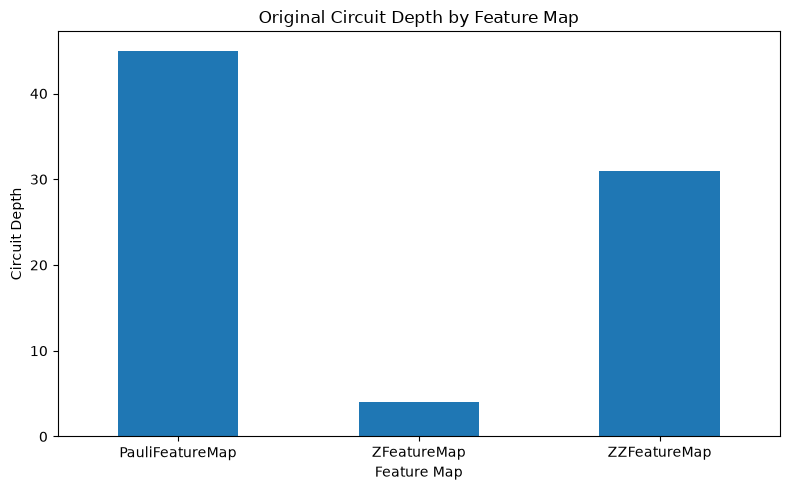

In [52]:
depth = df.groupby("feature_map")["depth"].mean()

plt.figure(figsize=(8, 5))
depth.plot(kind="bar")

plt.title("Original Circuit Depth by Feature Map")
plt.xlabel("Feature Map")
plt.ylabel("Circuit Depth")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "original_circuit_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

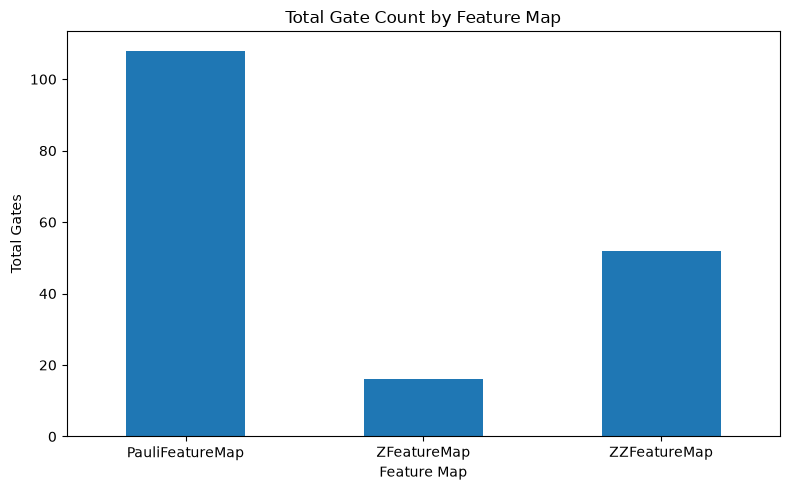

In [53]:
gates = df.groupby("feature_map")["total_gates"].mean()

plt.figure(figsize=(8, 5))
gates.plot(kind="bar")

plt.title("Total Gate Count by Feature Map")
plt.xlabel("Feature Map")
plt.ylabel("Total Gates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("total_gate_count.png", dpi=300, bbox_inches="tight")
plt.show()

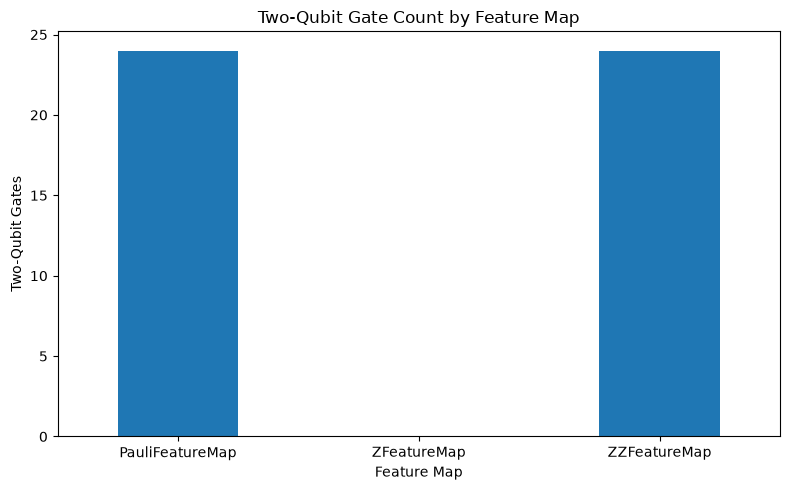

In [54]:
two_qubit = df.groupby("feature_map")["two_qubit_gates"].mean()

plt.figure(figsize=(8, 5))
two_qubit.plot(kind="bar")

plt.title("Two-Qubit Gate Count by Feature Map")
plt.xlabel("Feature Map")
plt.ylabel("Two-Qubit Gates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("two_qubit_gate_count.png", dpi=300, bbox_inches="tight")
plt.show()

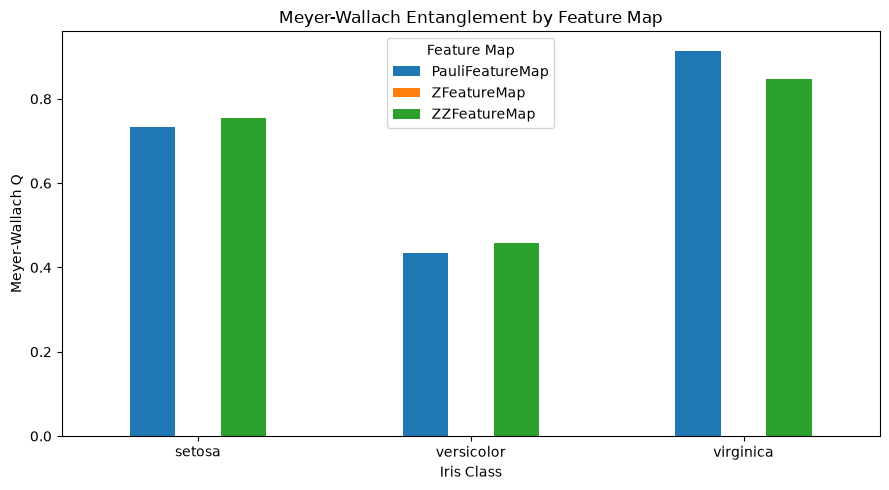

In [55]:
entanglement = df.pivot(
    index="sample",
    columns="feature_map",
    values="meyer_wallach_Q"
)

entanglement.plot(kind="bar", figsize=(9, 5))

plt.title("Meyer-Wallach Entanglement by Feature Map")
plt.xlabel("Iris Class")
plt.ylabel("Meyer-Wallach Q")
plt.xticks(rotation=0)
plt.legend(title="Feature Map")

plt.tight_layout()
plt.savefig("meyer_wallach_entanglement.png", dpi=300, bbox_inches="tight")
plt.show()

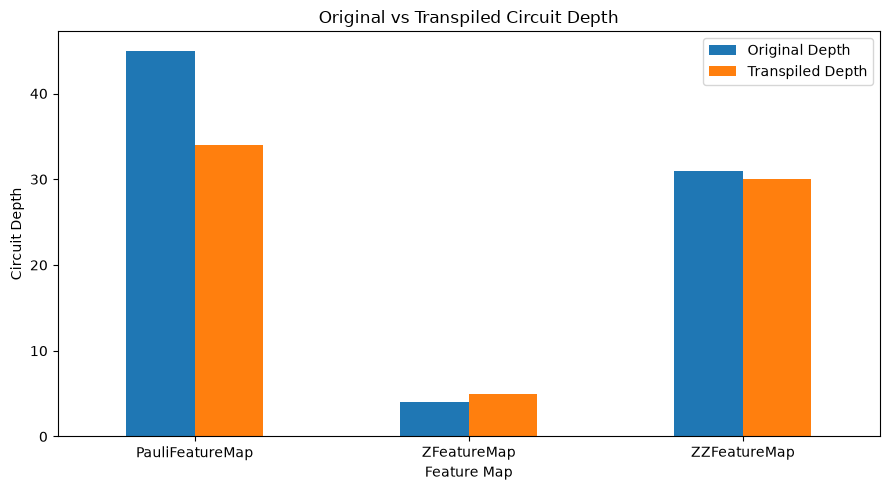

In [56]:
depth_comparison = df.groupby("feature_map")[
    ["depth", "transpiled_depth"]
].mean()

depth_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Original vs Transpiled Circuit Depth")
plt.xlabel("Feature Map")
plt.ylabel("Circuit Depth")
plt.xticks(rotation=0)

plt.legend(["Original Depth", "Transpiled Depth"])

plt.tight_layout()
plt.savefig("original_vs_transpiled_depth.png", dpi=300, bbox_inches="tight")
plt.show()

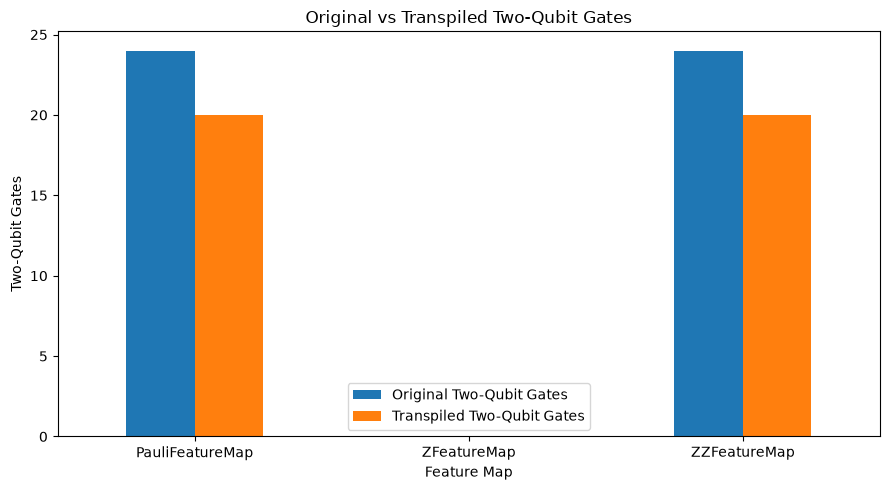

In [57]:
two_qubit_comparison = df.groupby("feature_map")[
    ["two_qubit_gates", "transpiled_two_qubit_gates"]
].mean()

two_qubit_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Original vs Transpiled Two-Qubit Gates")
plt.xlabel("Feature Map")
plt.ylabel("Two-Qubit Gates")
plt.xticks(rotation=0)

plt.legend([
    "Original Two-Qubit Gates",
    "Transpiled Two-Qubit Gates"
])


plt.tight_layout()
plt.savefig("original_vs_transpiled_2q_gates.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
setosa_results = {
    "ZFeatureMap": {
        "0001": 1589,
        "0011": 1439,
        "0101": 311,
        "0111": 310
    },
    "ZZFeatureMap": {
        "1110": 974,
        "1100": 673,
        "0000": 434,
        "0110": 347
    },
    "PauliFeatureMap": {
        "0010": 1321,
        "1100": 535,
        "1000": 448,
        "0000": 433
    }
}

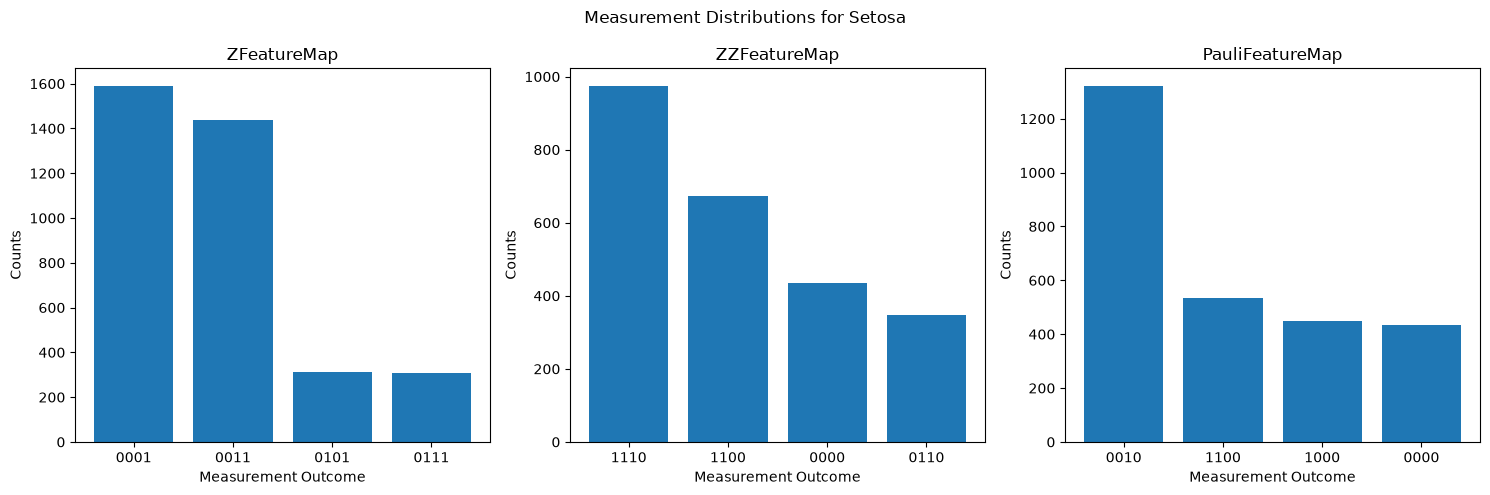

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (feature_map, results) in zip(
    axes, setosa_results.items()
):
    ax.bar(results.keys(), results.values())

    ax.set_title(feature_map)
    ax.set_xlabel("Measurement Outcome")
    ax.set_ylabel("Counts")

plt.suptitle("Measurement Distributions for Setosa")
plt.tight_layout()
plt.savefig("measurement_distributions_setosa.png", dpi=300, bbox_inches="tight")
plt.show()

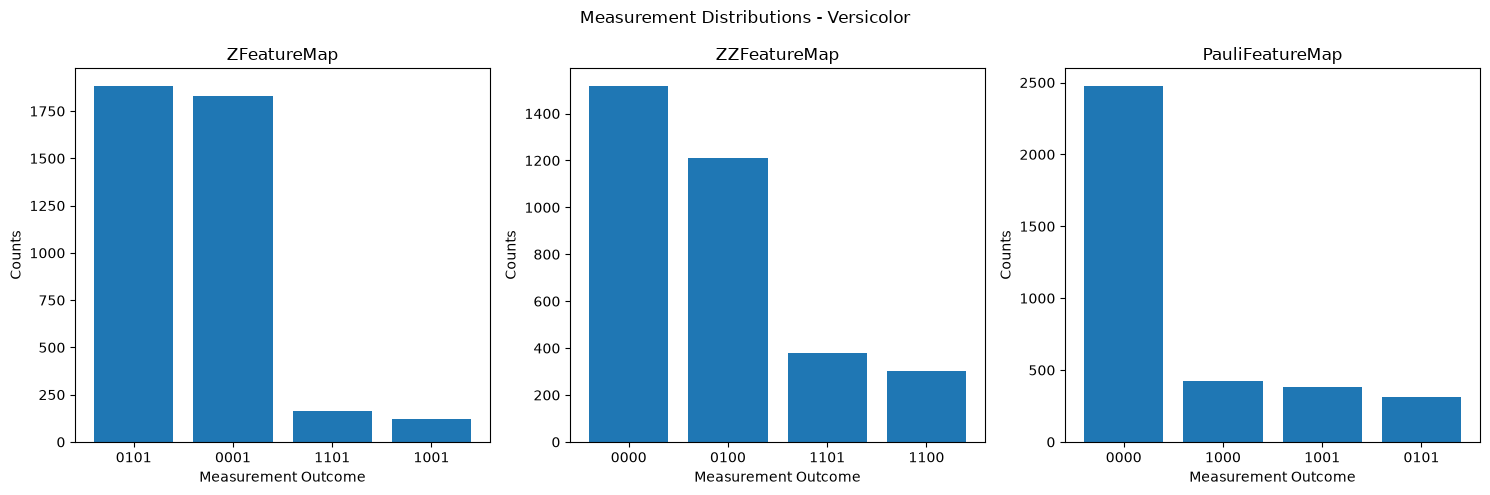

In [59]:
import matplotlib.pyplot as plt

versicolor_results = {
    "ZFeatureMap": {
        "0101": 1882,
        "0001": 1828,
        "1101": 166,
        "1001": 124
    },
    "ZZFeatureMap": {
        "0000": 1517,
        "0100": 1212,
        "1101": 378,
        "1100": 303
    },
    "PauliFeatureMap": {
        "0000": 2475,
        "1000": 421,
        "1001": 385,
        "0101": 314
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (feature_map, outcomes) in zip(
    axes, versicolor_results.items()
):
    ax.bar(outcomes.keys(), outcomes.values())
    ax.set_title(feature_map)
    ax.set_xlabel("Measurement Outcome")
    ax.set_ylabel("Counts")

fig.suptitle("Measurement Distributions - Versicolor")

plt.tight_layout()

plt.savefig(
    "measurement_distribution_versicolor.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

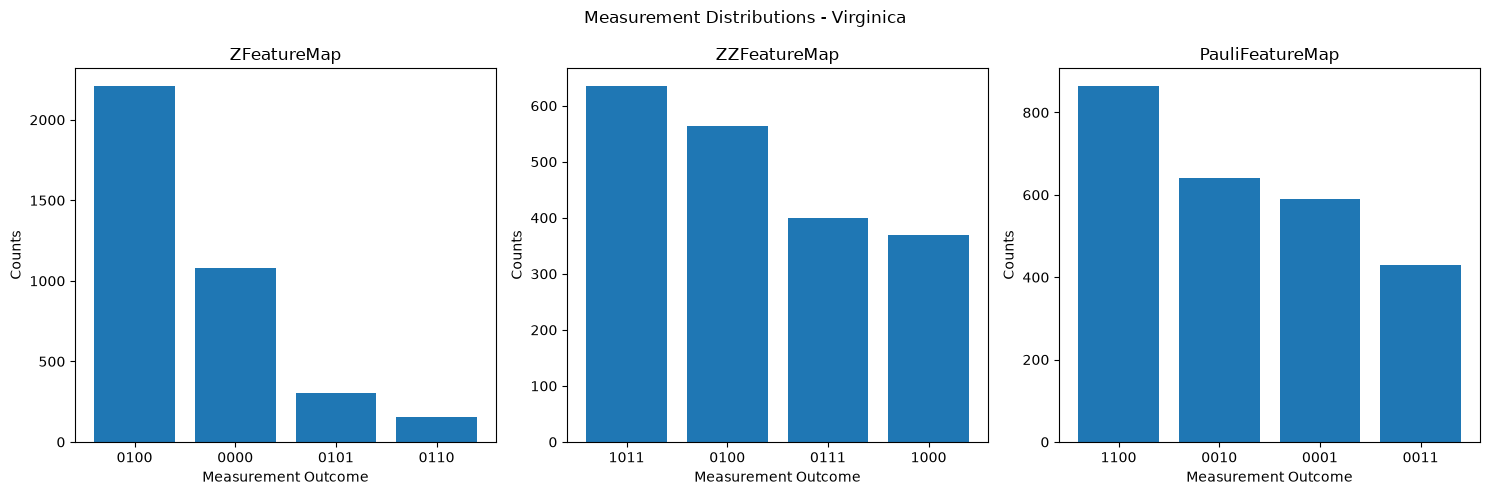

In [60]:
virginica_results = {
    "ZFeatureMap": {
        "0100": 2209,
        "0000": 1078,
        "0101": 305,
        "0110": 157
    },
    "ZZFeatureMap": {
        "1011": 635,
        "0100": 564,
        "0111": 399,
        "1000": 369
    },
    "PauliFeatureMap": {
        "1100": 864,
        "0010": 640,
        "0001": 591,
        "0011": 429
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (feature_map, outcomes) in zip(
    axes, virginica_results.items()
):
    ax.bar(outcomes.keys(), outcomes.values())
    ax.set_title(feature_map)
    ax.set_xlabel("Measurement Outcome")
    ax.set_ylabel("Counts")

fig.suptitle("Measurement Distributions - Virginica")

plt.tight_layout()

plt.savefig(
    "measurement_distribution_virginica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()